In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import io

In [3]:
df=pd.read_csv(r"C:\Users\vamsh\Downloads\Book1sample.csv")
df.head()

,Learner SignUp DateTime,Opportunity Name,Opportunity Category,Opportunity End Date,Date of Birth,Gender,City,State,Country,Institution Name,Graduation Date,Current Student Status,Current/Intended Major,Entry created at,Status Description,Apply Date,Opportunity Start Date,Full_Name,Age
0,14-06-2023,Career Essentials: Getting Started with Your P...,Course,29-06-2024,12-01-2001,Female,Peshawar,Pakistan,Pakistan,Nwihs,01-11-2023,Undergraduate Student,Radiology,11-03-2024,Started,14-06-2023,03-11-2022,Faria Khan,23
1,01-05-2023,Career Essentials: Getting Started with Your P...,Course,29-06-2024,16-08-2000,Female,vikarabad,Telangana,India,Saint Louis University,01-05-2025,Graduate Program Student,Information Systems,11-03-2024,Started,01-05-2023,03-11-2022,Poojitha Bembadi,24
2,09-04-2023,Career Essentials: Getting Started with Your P...,Course,29-06-2024,27-01-2002,Male,Chicago,Illinois,United States,Illinois Institute of Technology,01-01-2025,Undergraduate Student,Computer Science,11-03-2024,Started,11-05-2023,03-11-2022,Emmanuel Thompson,22
3,29-08-2023,Career Essentials: Getting Started with Your P...,Course,29-06-2024,01-11-1999,Female,Saint Louis,Missouri,United States,Saint Louis University,01-05-2025,Graduate Program Student,Information Systems,11-03-2024,Team Allocated,09-10-2023,03-11-2022,Amrutha Varshini Anagurthi,25
4,06-01-2023,Career Essentials: Getting Started with Your P...,Course,29-06-2024,19-04-2000,Male,Saint Louis,Missouri,United States,Saint Louis University,01-12-2024,Graduate Program Student,Computer Science,11-03-2024,Started,06-01-2023,03-11-2022,Vinay Varshith Pechetti,24


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Learner SignUp DateTime  8558 non-null   object
 1   Opportunity Name         8558 non-null   object
 2   Opportunity Category     8558 non-null   object
 3   Opportunity End Date     8558 non-null   object
 4   Date of Birth            8558 non-null   object
 5   Gender                   8558 non-null   object
 6   City                     8558 non-null   object
 7   State                    8558 non-null   object
 8   Country                  8558 non-null   object
 9   Institution Name         8558 non-null   object
 10  Graduation Date          8558 non-null   object
 11  Current Student Status   8558 non-null   object
 12  Current/Intended Major   8558 non-null   object
 13  Entry created at         8558 non-null   object
 14  Status Description       8558 non-null  

Starting comprehensive model comparison...
Data preparation completed:
Training set shape: (6846, 10)
Testing set shape: (1712, 10)
Dropout rate in training set: 8.21%

Training Logistic Regression...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1571
           1       0.00      0.00      0.00       141

    accuracy                           0.92      1712
   macro avg       0.46      0.50      0.48      1712
weighted avg       0.84      0.92      0.88      1712


Training Decision Tree...

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1571
           1       0.59      0.48      0.53       141

    accuracy                           0.93      1712
   macro avg       0.77      0.73      0.75      1712
weighted avg       0.92      0.93      0.93      1712


Training Random Forest...



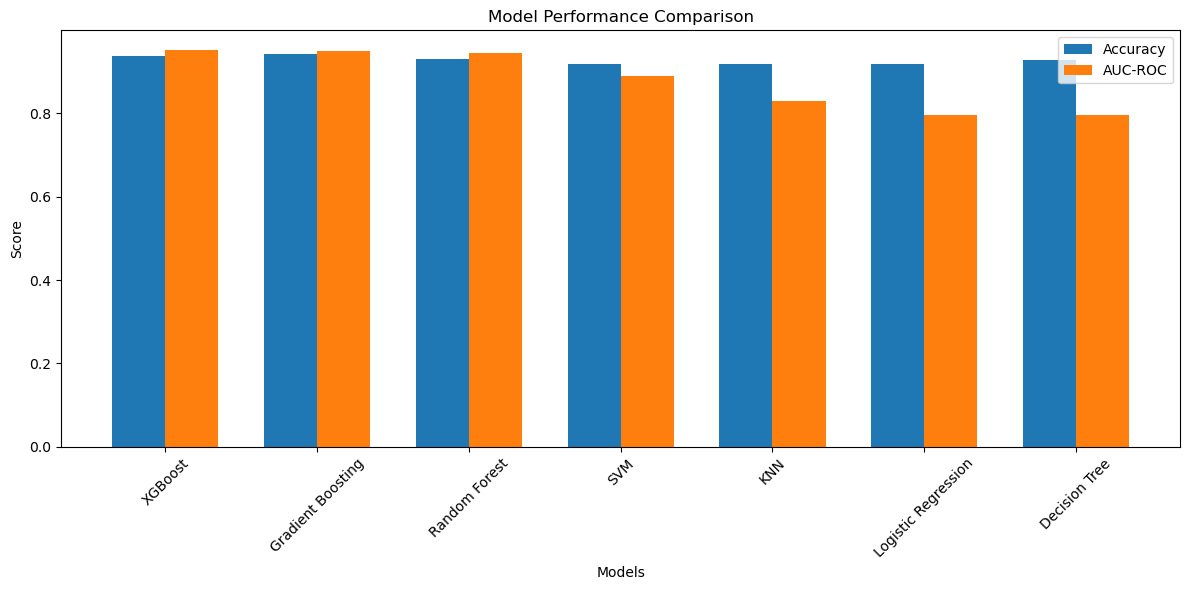

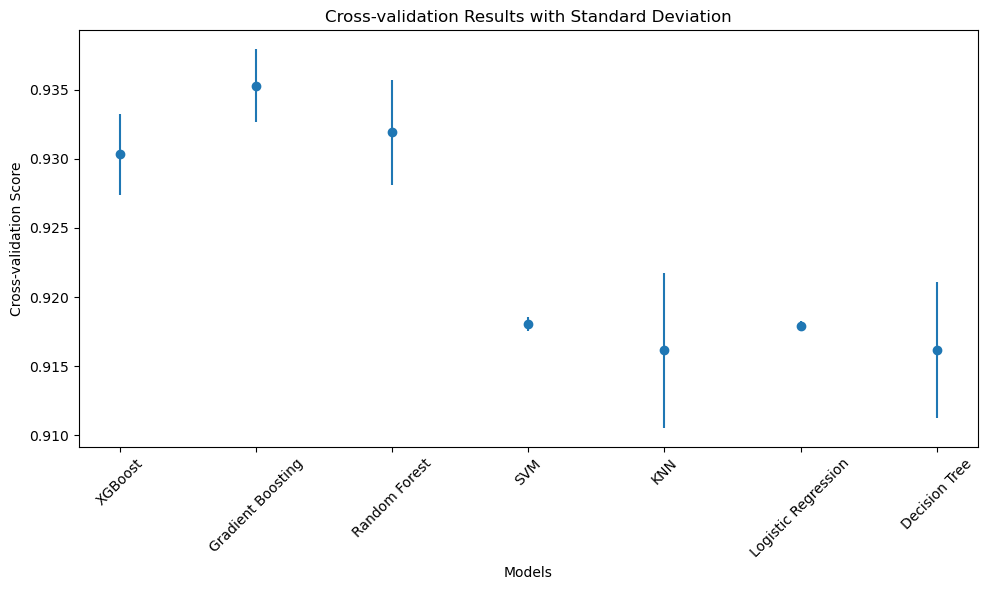


Final Model Comparison:
              Model  Accuracy  AUC-ROC  CV Mean   CV Std
            XGBoost  0.938084 0.951899 0.930324 0.002957
  Gradient Boosting  0.942757 0.949278 0.935290 0.002644
      Random Forest  0.931659 0.944696 0.931931 0.003797
                SVM  0.918808 0.889085 0.918054 0.000534
                KNN  0.918224 0.830555 0.916155 0.005619
Logistic Regression  0.917640 0.795879 0.917908 0.000344
      Decision Tree  0.929322 0.795213 0.916154 0.004917

Best performing model: XGBoost
Accuracy: 0.9381
AUC-ROC: 0.9519
Cross-validation Score: 0.9303 (±0.0030)


In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Import multiple algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

class StudentDropoutPredictor:
    def __init__(self, df):
        self.df = df
        self.models = {
            'Logistic Regression': LogisticRegression(random_state=42),
            'Decision Tree': DecisionTreeClassifier(random_state=42),
            'Random Forest': RandomForestClassifier(random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'SVM': SVC(random_state=42, probability=True),
            'KNN': KNeighborsClassifier(),
            'XGBoost': XGBClassifier(random_state=42)
        }
        self.model_scores = {}
        
    def prepare_data(self):
        """Prepare data for modeling"""
        # Create target variable
        self.df['dropout'] = self.df['Status Description'].map(
            lambda x: 1 if x in ['Dropped Out', 'Withdraw'] else 0
        )
        
        # Convert dates and create features
        date_columns = ['Learner SignUp DateTime', 'Opportunity End Date', 
                       'Date of Birth', 'Graduation Date', 'Entry created at', 
                       'Apply Date', 'Opportunity Start Date']
        
        for col in date_columns:
            self.df[col] = pd.to_datetime(self.df[col], format='%d-%m-%Y', errors='coerce')
        
        # Create derived features
        self.df['days_to_start'] = (self.df['Opportunity Start Date'] - self.df['Learner SignUp DateTime']).dt.days
        self.df['days_to_end'] = (self.df['Opportunity End Date'] - self.df['Learner SignUp DateTime']).dt.days
        self.df['days_to_graduate'] = (self.df['Graduation Date'] - self.df['Learner SignUp DateTime']).dt.days
        self.df['application_processing_time'] = (self.df['Entry created at'] - self.df['Apply Date']).dt.days
        
        # Handle categorical variables
        categorical_columns = ['Gender', 'Country', 'Current Student Status', 
                             'Current/Intended Major', 'Opportunity Category']
        
        for col in categorical_columns:
            le = LabelEncoder()
            self.df[col + '_encoded'] = le.fit_transform(self.df[col])
        
        # Select features for modeling
        self.feature_columns = [
            'Age', 'days_to_start', 'days_to_end', 'days_to_graduate',
            'application_processing_time', 'Gender_encoded', 'Country_encoded',
            'Current Student Status_encoded', 'Current/Intended Major_encoded',
            'Opportunity Category_encoded'
        ]
        
        # Prepare X and y
        X = self.df[self.feature_columns]
        y = self.df['dropout']
        
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=self.feature_columns)
        
        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        print("Data preparation completed:")
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Testing set shape: {self.X_test.shape}")
        print(f"Dropout rate in training set: {self.y_train.mean():.2%}")
        
    def train_and_evaluate_models(self):
        """Train and evaluate all models"""
        results = []
        
        for name, model in self.models.items():
            print(f"\nTraining {name}...")
            
            # Train model
            model.fit(self.X_train, self.y_train)
            
            # Make predictions
            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)[:, 1]
            
            # Calculate metrics
            accuracy = model.score(self.X_test, self.y_test)
            auc_score = roc_auc_score(self.y_test, y_pred_proba)
            
            # Cross-validation score
            cv_scores = cross_val_score(model, self.X_train, self.y_train, cv=5)
            
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'AUC-ROC': auc_score,
                'CV Mean': cv_scores.mean(),
                'CV Std': cv_scores.std()
            })
            
            # Print detailed report
            print(f"\nClassification Report for {name}:")
            print(classification_report(self.y_test, y_pred))
            
            # Store model scores
            self.model_scores[name] = {
                'accuracy': accuracy,
                'auc': auc_score,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std()
            }
        
        # Create comparison DataFrame
        self.results_df = pd.DataFrame(results)
        self.results_df = self.results_df.sort_values('AUC-ROC', ascending=False)
        
        return self.results_df
    
    def plot_model_comparison(self):
        """Plot model comparison results"""
        # Plot 1: Model Performance Comparison
        plt.figure(figsize=(12, 6))
        x = np.arange(len(self.results_df))
        width = 0.35
        
        plt.bar(x - width/2, self.results_df['Accuracy'], width, label='Accuracy')
        plt.bar(x + width/2, self.results_df['AUC-ROC'], width, label='AUC-ROC')
        
        plt.xlabel('Models')
        plt.ylabel('Score')
        plt.title('Model Performance Comparison')
        plt.xticks(x, self.results_df['Model'], rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Plot 2: Cross-validation Results
        plt.figure(figsize=(10, 6))
        plt.errorbar(self.results_df['Model'], self.results_df['CV Mean'], 
                    yerr=self.results_df['CV Std'], fmt='o')
        plt.xlabel('Models')
        plt.ylabel('Cross-validation Score')
        plt.title('Cross-validation Results with Standard Deviation')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Execute the analysis
def run_analysis(df):
    print("Starting comprehensive model comparison...")
    
    # Initialize predictor
    predictor = StudentDropoutPredictor(df)
    
    # Prepare data
    predictor.prepare_data()
    
    # Train and evaluate models
    results = predictor.train_and_evaluate_models()
    
    # Plot comparisons
    predictor.plot_model_comparison()
    
    # Print final results
    print("\nFinal Model Comparison:")
    print(results.to_string(index=False))
    
    # Identify best model
    best_model = results.iloc[0]
    print(f"\nBest performing model: {best_model['Model']}")
    print(f"Accuracy: {best_model['Accuracy']:.4f}")
    print(f"AUC-ROC: {best_model['AUC-ROC']:.4f}")
    print(f"Cross-validation Score: {best_model['CV Mean']:.4f} (±{best_model['CV Std']:.4f})")
    
    return predictor

# Run the analysis (assuming df is your DataFrame)
predictor = run_analysis(df)

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

class AdvancedStudentDropoutPredictor:
    def __init__(self, df):
        self.df = df
        self.models = {
            'Logistic Regression': {
                'model': LogisticRegression(random_state=42),
                'params': {
                    'C': [0.001, 0.01, 0.1, 1, 10],
                    'penalty': ['l1', 'l2'],
                    'solver': ['liblinear']
                }
            },
            'Decision Tree': {
                'model': DecisionTreeClassifier(random_state=42),
                'params': {
                    'max_depth': [None, 10, 20, 30],
                    'min_samples_split': [2, 5, 10]
                }
            },
            'Random Forest': {
                'model': RandomForestClassifier(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [10, 20, None],
                    'min_samples_split': [2, 5]
                }
            },
            'Gradient Boosting': {
                'model': GradientBoostingClassifier(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'learning_rate': [0.01, 0.1],
                    'max_depth': [3, 5, 7]
                }
            },
            'Support Vector Machine': {
                'model': SVC(probability=True, random_state=42),
                'params': {
                    'C': [0.1, 1, 10],
                    'kernel': ['linear', 'rbf']
                }
            },
            'K-Neighbors Classifier': {
                'model': KNeighborsClassifier(),
                'params': {
                    'n_neighbors': [3, 5, 7, 9],
                    'weights': ['uniform', 'distance']
                }
            },
            'XGBoost': {
                'model': XGBClassifier(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5, 7],
                    'learning_rate': [0.01, 0.1]
                }
            }
        }
        self.best_models = {}
        self.feature_importances = {}
        self.scaler = StandardScaler()
        self.encoders = {}
        
    def prepare_data(self):
        """Prepare data with enhanced feature engineering"""
        print("Starting data preparation...")
        
        # Create target variable
        self.df['dropout'] = self.df['Status Description'].map(
            lambda x: 1 if x in ['Dropped Out', 'Withdraw'] else 0
        )
        
        # Convert dates and create features
        date_columns = ['Learner SignUp DateTime', 'Opportunity End Date', 
                        'Date of Birth', 'Graduation Date', 'Entry created at', 
                        'Apply Date', 'Opportunity Start Date']
        
        for col in date_columns:
            self.df[col] = pd.to_datetime(self.df[col], format='%d-%m-%Y', errors='coerce')
        
        # Enhanced feature engineering
        self.df['days_to_start'] = (self.df['Opportunity Start Date'] - self.df['Learner SignUp DateTime']).dt.days
        self.df['days_to_end'] = (self.df['Opportunity End Date'] - self.df['Learner SignUp DateTime']).dt.days
        self.df['days_to_graduate'] = (self.df['Graduation Date'] - self.df['Learner SignUp DateTime']).dt.days
        self.df['application_processing_time'] = (self.df['Entry created at'] - self.df['Apply Date']).dt.days
        self.df['program_duration'] = (self.df['Opportunity End Date'] - self.df['Opportunity Start Date']).dt.days
        
        # Handle categorical variables
        categorical_columns = ['Gender', 'Country', 'Current Student Status', 
                               'Current/Intended Major', 'Opportunity Category']
        
        for col in categorical_columns:
            self.encoders[col] = LabelEncoder()
            self.df[col + '_encoded'] = self.encoders[col].fit_transform(self.df[col])
        
        # Select features
        self.feature_columns = [
            'Age', 'days_to_start', 'days_to_end', 'days_to_graduate',
            'application_processing_time', 'program_duration',
            'Gender_encoded', 'Country_encoded', 'Current Student Status_encoded',
            'Current/Intended Major_encoded', 'Opportunity Category_encoded'
        ]
        
        # Prepare X and y
        X = self.df[self.feature_columns]
        y = self.df['dropout']
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=self.feature_columns)
        
        # Split data with stratification
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        print("\nData preparation completed:")
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Testing set shape: {self.X_test.shape}")
        print(f"Dropout rate: {self.y_train.mean():.2%}")
        
    def train_and_evaluate_models(self):
        """Train models with hyperparameter tuning and comprehensive evaluation"""
        results = []
        
        for name, model_info in self.models.items():
            print(f"\nTraining {name} with hyperparameter tuning...")
            
            # Perform grid search
            grid_search = GridSearchCV(
                model_info['model'],
                model_info['params'],
                cv=5,
                scoring='roc_auc',
                n_jobs=-1
            )
            grid_search.fit(self.X_train, self.y_train)
            
            # Store best model
            self.best_models[name] = grid_search.best_estimator_
            
            # Make predictions
            y_pred = grid_search.predict(self.X_test)
            y_pred_proba = grid_search.predict_proba(self.X_test)[:, 1]
            
            # Calculate metrics
            accuracy = grid_search.score(self.X_test, self.y_test)
            auc_score = roc_auc_score(self.y_test, y_pred_proba)
            cv_scores = cross_val_score(grid_search.best_estimator_, 
                                         self.X_train, self.y_train, cv=5)
            
            # Store results
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'AUC-ROC': auc_score,
                'CV Mean': cv_scores.mean(),
                'CV Std': cv_scores.std(),
                'Best Parameters': grid_search.best_params_
            })
            
            # Print detailed report
            print(f"\nBest parameters for {name}:")
            print(grid_search.best_params_)
            print(f"\nClassification Report for {name}:")
            print(classification_report(self.y_test, y_pred))
            
            # Calculate and plot confusion matrix
            self.plot_confusion_matrix(y_pred, name)
            
            # Calculate ROC curve
            self.plot_roc_curve(y_pred_proba, name)
            
            # Calculate feature importance
            if hasattr(grid_search.best_estimator_, 'feature_importances_'):
                self.feature_importances[name] = pd.DataFrame({
                    'feature': self.feature_columns,
                    'importance': grid_search.best_estimator_.feature_importances_
                }).sort_values('importance', ascending=False)
            elif name == 'Logistic Regression':
                self.feature_importances[name] = pd.DataFrame({
                    'feature': self.feature_columns,
                    'importance': abs(grid_search.best_estimator_.coef_[0])
                }).sort_values('importance', ascending=False)

        self.results_df = pd.DataFrame(results)
        self.plot_model_comparison()
        return self.results_df

    def plot_confusion_matrix(self, y_pred, model_name):
        """Plot confusion matrix for the model"""
        cm = confusion_matrix(self.y_test, y_pred)

        # Print the confusion matrix
        print(f"\nConfusion Matrix for {model_name}:\n")
        print(pd.DataFrame(cm, columns=['Predicted: Not Dropped Out', 'Predicted: Dropped Out'],
                           index=['True: Not Dropped Out', 'True: Dropped Out']))

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Not Dropped Out', 'Dropped Out'],
                    yticklabels=['Not Dropped Out', 'Dropped Out'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'Confusion Matrix for {model_name}')
        plt.show()

    def plot_roc_curve(self, y_pred_proba, model_name):
        """Plot ROC curve for the model"""
        fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label='ROC curve', color='blue')
        plt.plot([0, 1], [0, 1], color='red', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {model_name}')
        plt.legend()
        plt.show()

    def plot_model_comparison(self):
        """Visualize comparison of model performance metrics"""
        plt.figure(figsize=(12, 8))
        sns.barplot(data=self.results_df, x='Model', y='AUC-ROC', palette='viridis')
        plt.title('Model Comparison: AUC-ROC')
        plt.xticks(rotation=45)
        plt.show()

    def save_best_model(self, model_name):
        """Save the best Random Forest model to disk"""
        if model_name in self.best_models:
            joblib.dump(self.best_models[model_name], f'{model_name.replace(" ", "_")}_model.pkl')
            print(f"Saved {model_name} model to disk.")
        else:
            print(f"{model_name} not found in the best models.")

    def feature_importance_summary(self):
        for name, importance_df in self.feature_importances.items():
            plt.figure(figsize=(10, 6))
            sns.barplot(data=importance_df.head(10), x='importance', y='feature', palette='viridis')
            # Add values on bars
            for index, value in enumerate(importance_df.head(10)['importance']):
                plt.text(value, index, f'{value:.2f}', va='center')  # Adjust the format as needed
            plt.title(f'Feature Importance for {name}')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.show()

# Example of using the class with a dataframe
# df = pd.read_csv('path_to_your_data.csv')
# predictor = AdvancedStudentDropoutPredictor(df)
# predictor.prepare_data()
# results = predictor.train_and_evaluate_models()
# print(results)
# predictor.save_best_model('Random Forest')
# predictor.feature_importance_summary()


Starting data preparation...

Data preparation completed:
Training set shape: (6846, 11)
Testing set shape: (1712, 11)
Dropout rate: 8.21%

Training Logistic Regression with hyperparameter tuning...

Best parameters for Logistic Regression:
{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1571
           1       0.00      0.00      0.00       141

    accuracy                           0.92      1712
   macro avg       0.46      0.50      0.48      1712
weighted avg       0.84      0.92      0.88      1712


Confusion Matrix for Logistic Regression:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1571                       0
True: Dropped Out                             141                       0


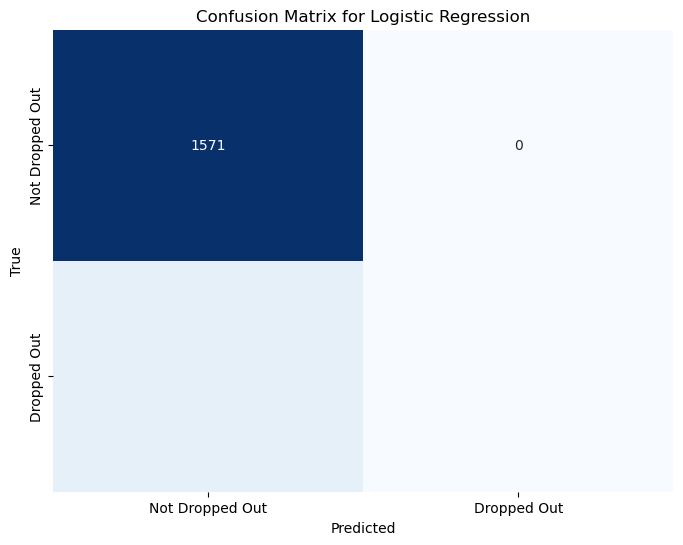

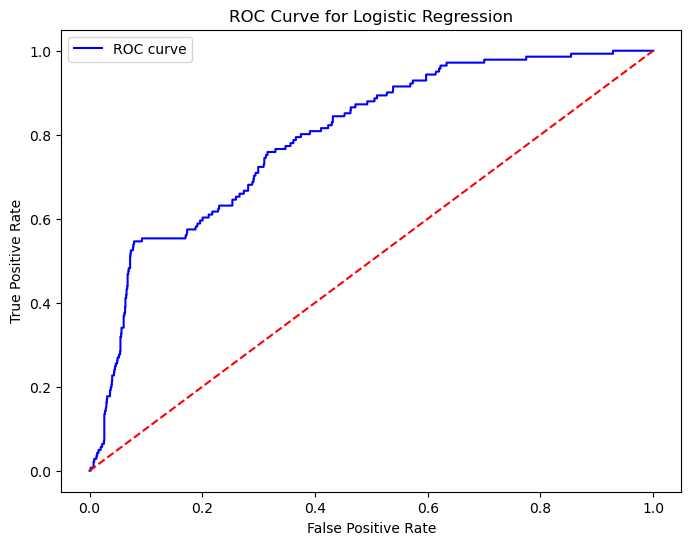


Training Decision Tree with hyperparameter tuning...

Best parameters for Decision Tree:
{'max_depth': 10, 'min_samples_split': 10}

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1571
           1       0.83      0.45      0.58       141

    accuracy                           0.95      1712
   macro avg       0.89      0.72      0.78      1712
weighted avg       0.94      0.95      0.94      1712


Confusion Matrix for Decision Tree:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1558                      13
True: Dropped Out                              78                      63


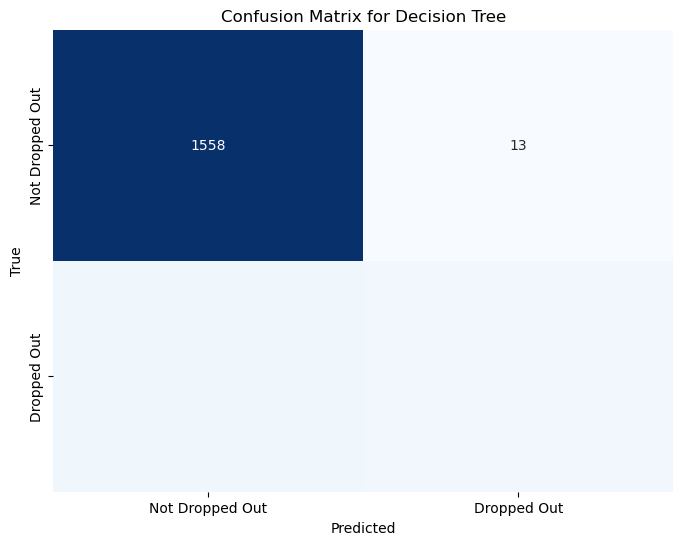

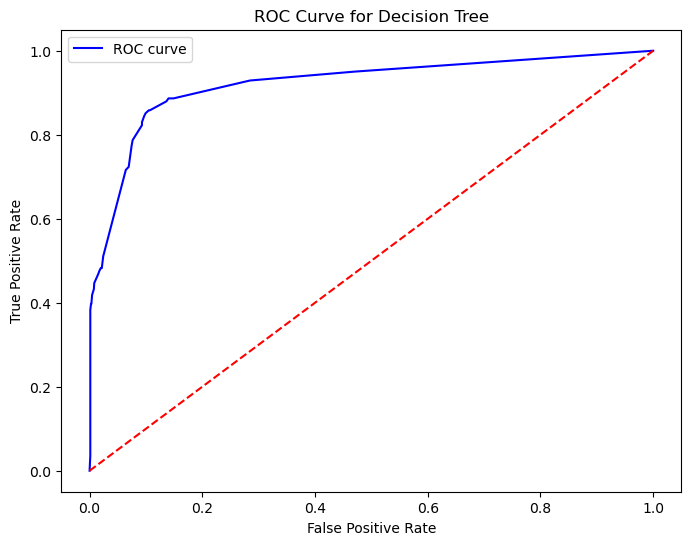


Training Random Forest with hyperparameter tuning...

Best parameters for Random Forest:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1571
           1       0.87      0.41      0.56       141

    accuracy                           0.95      1712
   macro avg       0.91      0.70      0.76      1712
weighted avg       0.94      0.95      0.94      1712


Confusion Matrix for Random Forest:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1562                       9
True: Dropped Out                              83                      58


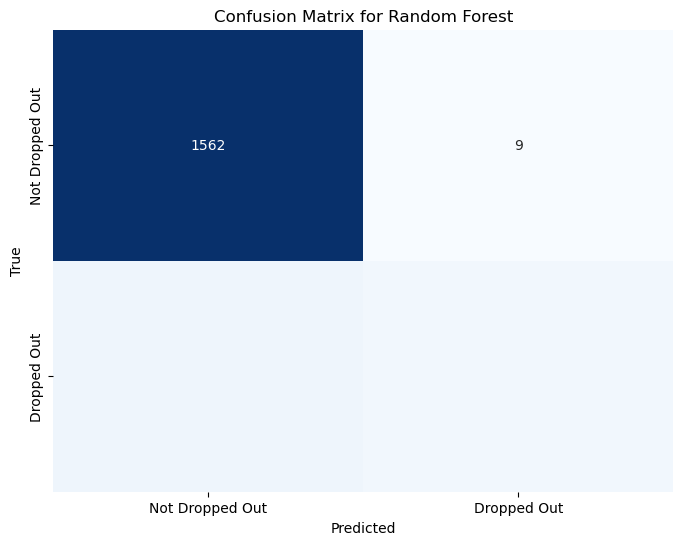

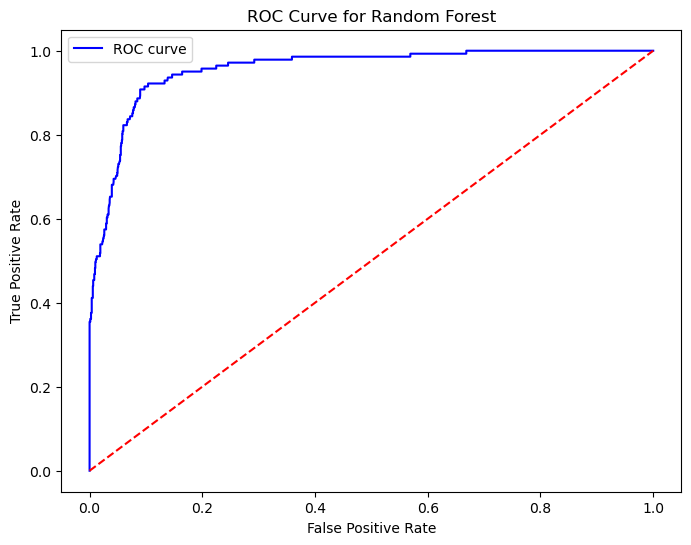


Training Gradient Boosting with hyperparameter tuning...

Best parameters for Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1571
           1       0.87      0.43      0.57       141

    accuracy                           0.95      1712
   macro avg       0.91      0.71      0.77      1712
weighted avg       0.94      0.95      0.94      1712


Confusion Matrix for Gradient Boosting:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1562                       9
True: Dropped Out                              81                      60


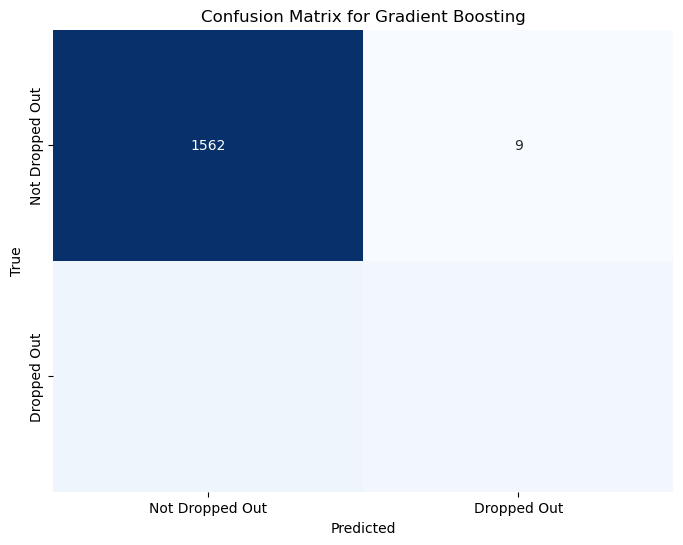

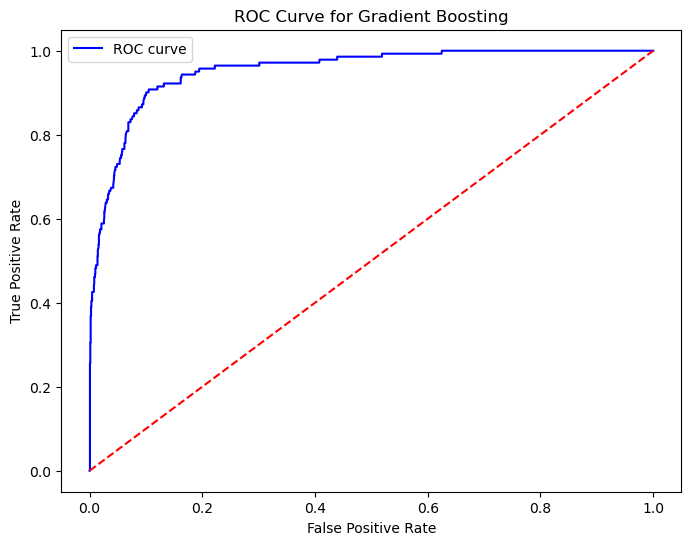


Training Support Vector Machine with hyperparameter tuning...

Best parameters for Support Vector Machine:
{'C': 10, 'kernel': 'rbf'}

Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1571
           1       0.68      0.36      0.47       141

    accuracy                           0.93      1712
   macro avg       0.81      0.67      0.72      1712
weighted avg       0.92      0.93      0.92      1712


Confusion Matrix for Support Vector Machine:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1547                      24
True: Dropped Out                              90                      51


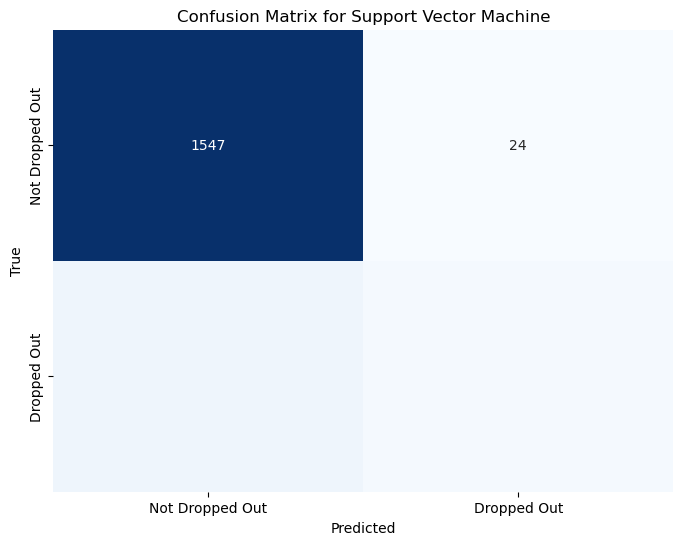

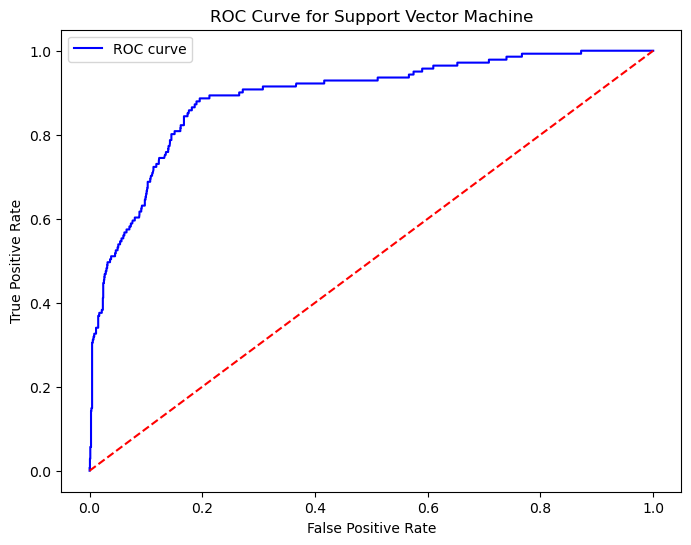


Training K-Neighbors Classifier with hyperparameter tuning...

Best parameters for K-Neighbors Classifier:
{'n_neighbors': 9, 'weights': 'uniform'}

Classification Report for K-Neighbors Classifier:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1571
           1       0.57      0.30      0.39       141

    accuracy                           0.92      1712
   macro avg       0.75      0.64      0.67      1712
weighted avg       0.91      0.92      0.91      1712


Confusion Matrix for K-Neighbors Classifier:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1539                      32
True: Dropped Out                              99                      42


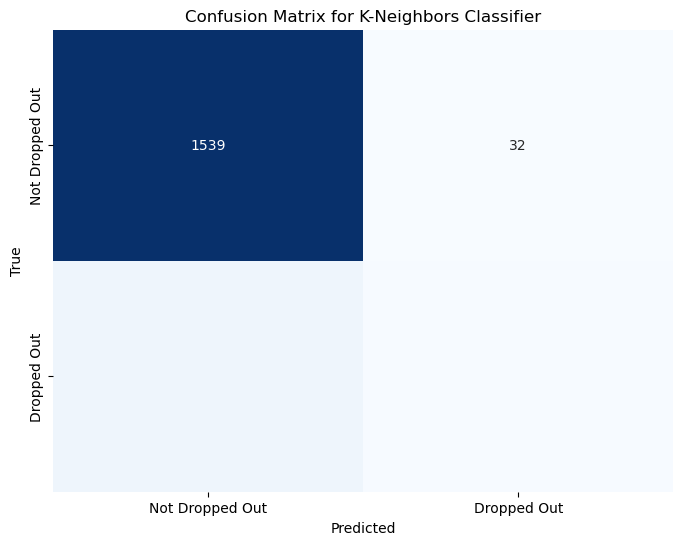

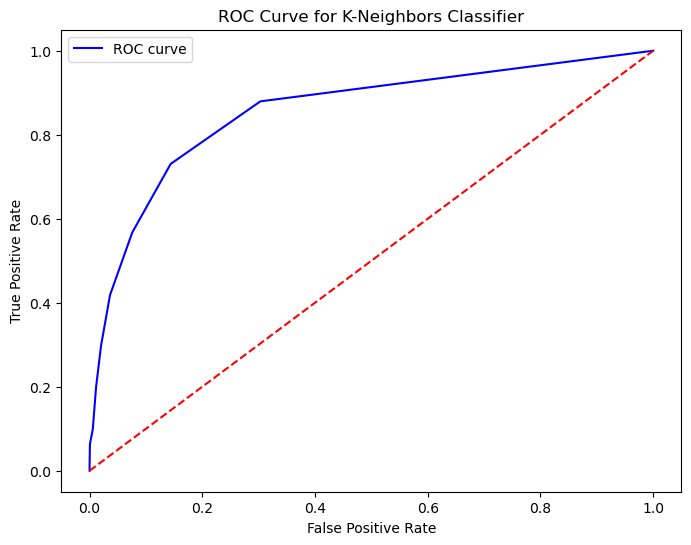


Training XGBoost with hyperparameter tuning...

Best parameters for XGBoost:
{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1571
           1       0.92      0.40      0.56       141

    accuracy                           0.95      1712
   macro avg       0.93      0.70      0.77      1712
weighted avg       0.95      0.95      0.94      1712


Confusion Matrix for XGBoost:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1566                       5
True: Dropped Out                              84                      57


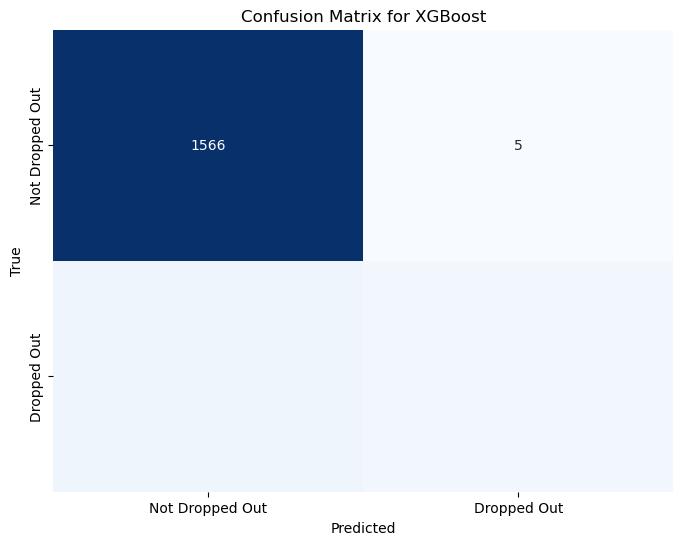

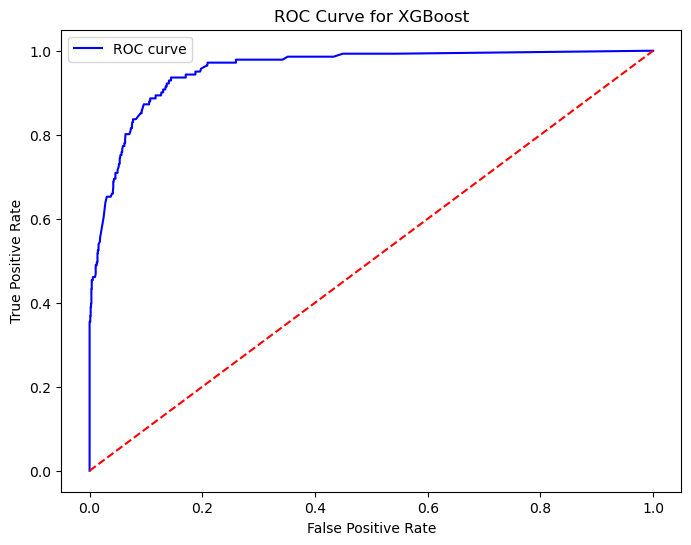

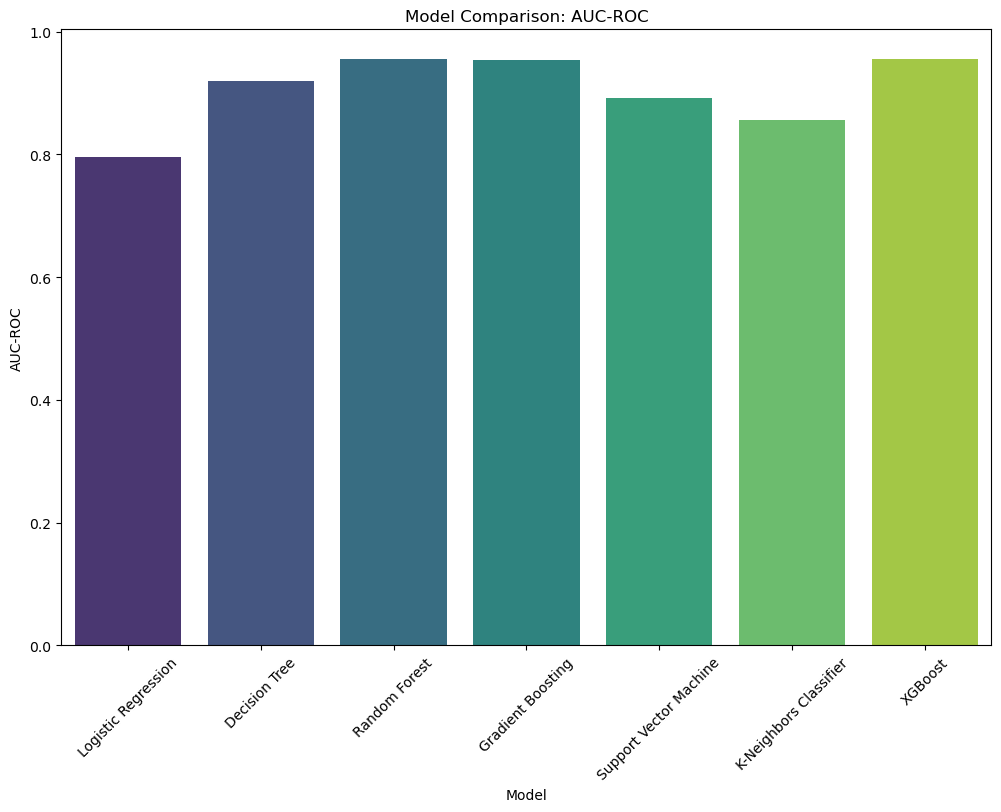

                    Model  Accuracy   AUC-ROC   CV Mean    CV Std  \
0     Logistic Regression  0.796015  0.796015  0.917908  0.000344   
1           Decision Tree  0.920099  0.920099  0.934999  0.003357   
2           Random Forest  0.955910  0.955910  0.940111  0.001312   
3       Gradient Boosting  0.953330  0.953330  0.939673  0.003089   
4  Support Vector Machine  0.891595  0.891635  0.930762  0.002558   
5  K-Neighbors Classifier  0.855944  0.855944  0.919515  0.005709   
6                 XGBoost  0.954603  0.954603  0.938650  0.002123   

                                     Best Parameters  
0  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}  
1         {'max_depth': 10, 'min_samples_split': 10}  
2  {'max_depth': 10, 'min_samples_split': 5, 'n_e...  
3  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...  
4                         {'C': 10, 'kernel': 'rbf'}  
5           {'n_neighbors': 9, 'weights': 'uniform'}  
6  {'learning_rate': 0.01, 'max_depth': 7, 'n_est...  
Saved D

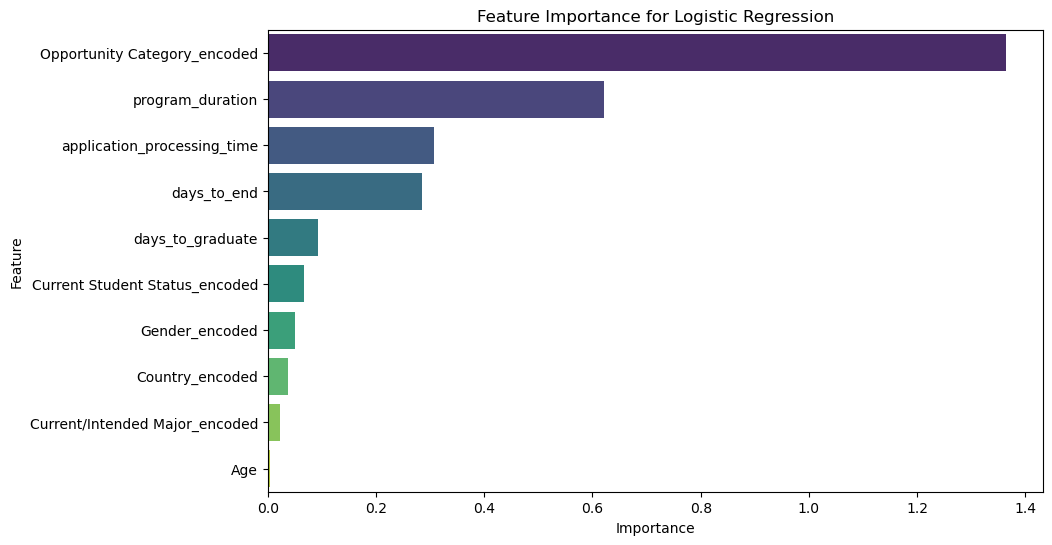

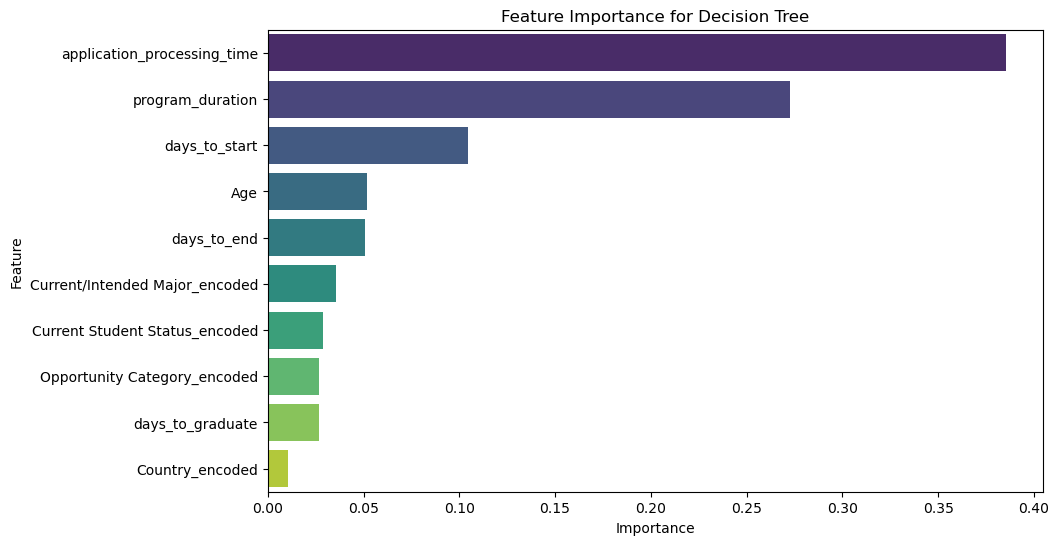

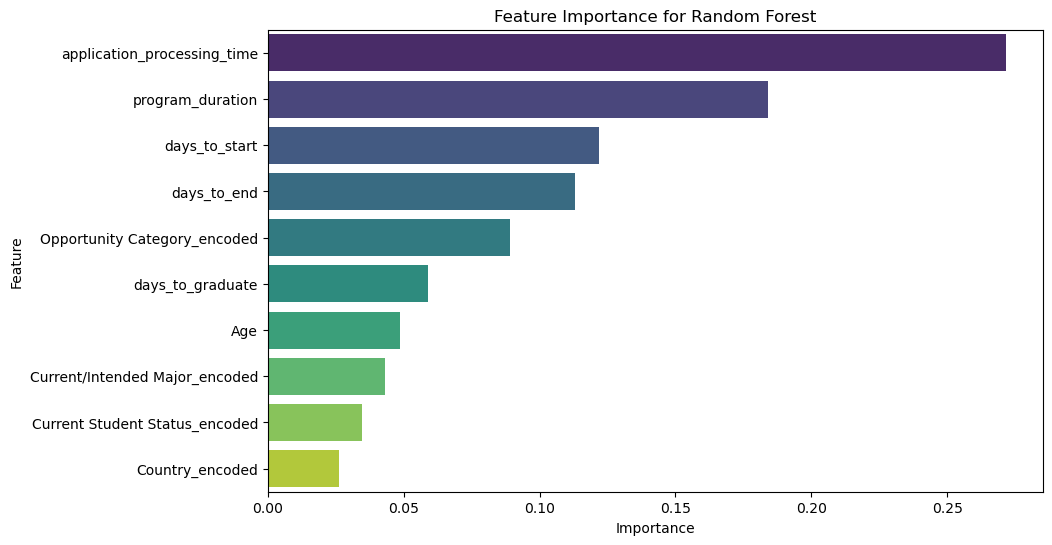

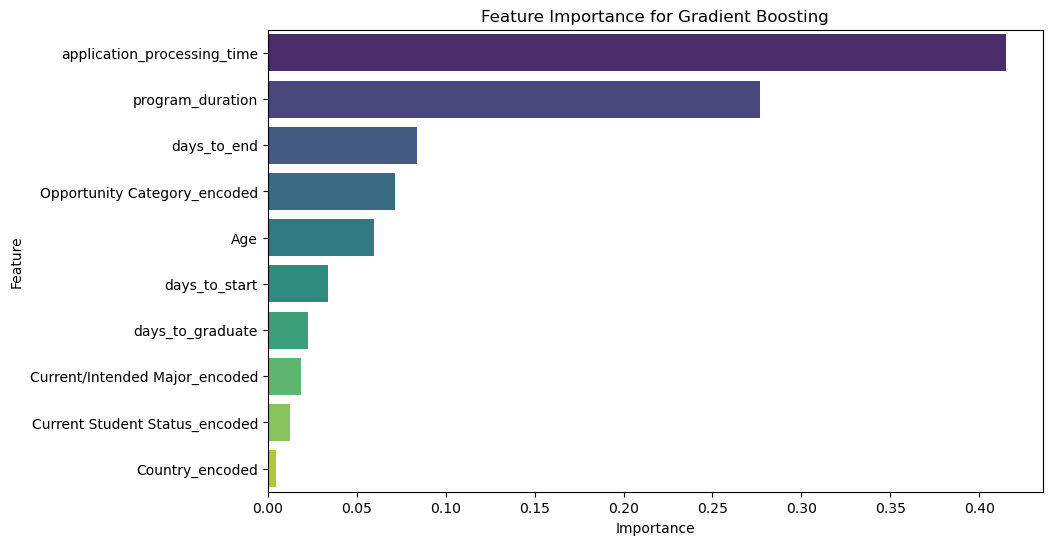

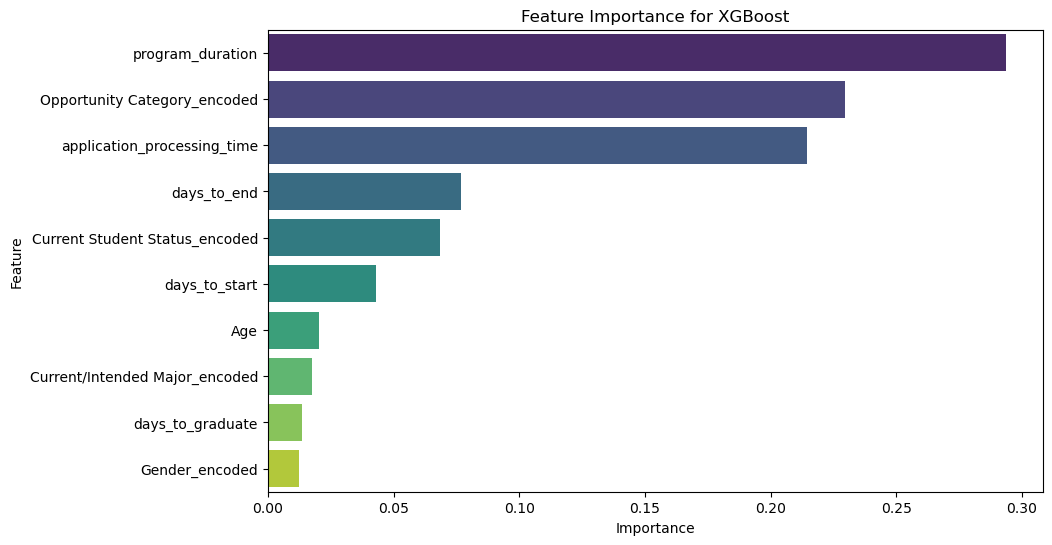

In [5]:
# Example of using the class with a dataframe
df=pd.read_csv(r"C:\Users\vamsh\Downloads\Book1sample.csv")
predictor = AdvancedStudentDropoutPredictor(df)
predictor.prepare_data()
results = predictor.train_and_evaluate_models()
print(results)
predictor.save_best_model('Decision Tree')
predictor.feature_importance_summary()

Starting data preparation...

Data preparation completed:
Training set shape: (6846, 11)
Testing set shape: (1712, 11)
Dropout rate: 8.21%

Training Logistic Regression with hyperparameter tuning...

Best parameters for Logistic Regression:
{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1571
           1       0.00      0.00      0.00       141

    accuracy                           0.92      1712
   macro avg       0.46      0.50      0.48      1712
weighted avg       0.84      0.92      0.88      1712


Confusion Matrix for Logistic Regression:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1571                       0
True: Dropped Out                             141                       0


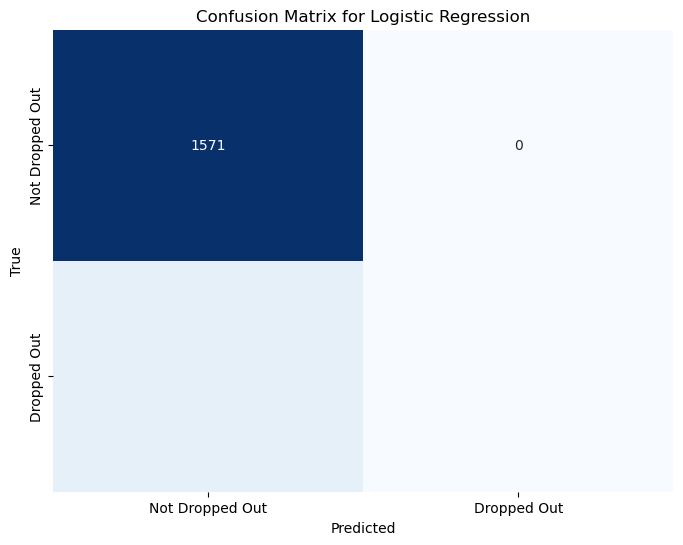

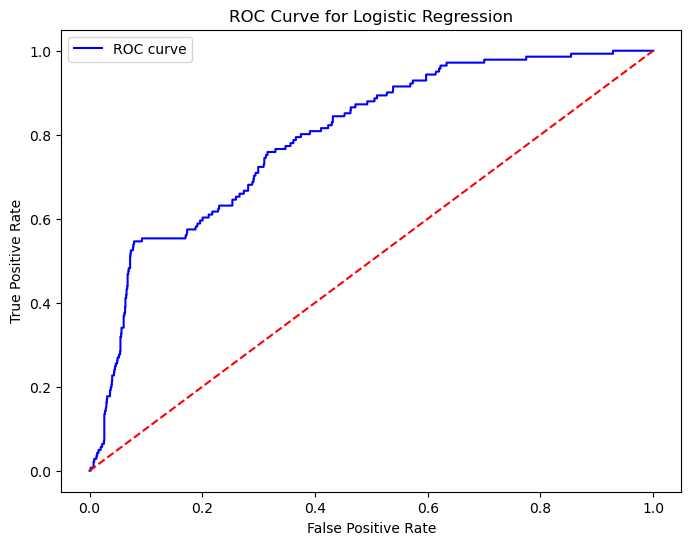


Training Decision Tree with hyperparameter tuning...

Best parameters for Decision Tree:
{'max_depth': 10, 'min_samples_split': 10}

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1571
           1       0.83      0.45      0.58       141

    accuracy                           0.95      1712
   macro avg       0.89      0.72      0.78      1712
weighted avg       0.94      0.95      0.94      1712


Confusion Matrix for Decision Tree:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1558                      13
True: Dropped Out                              78                      63


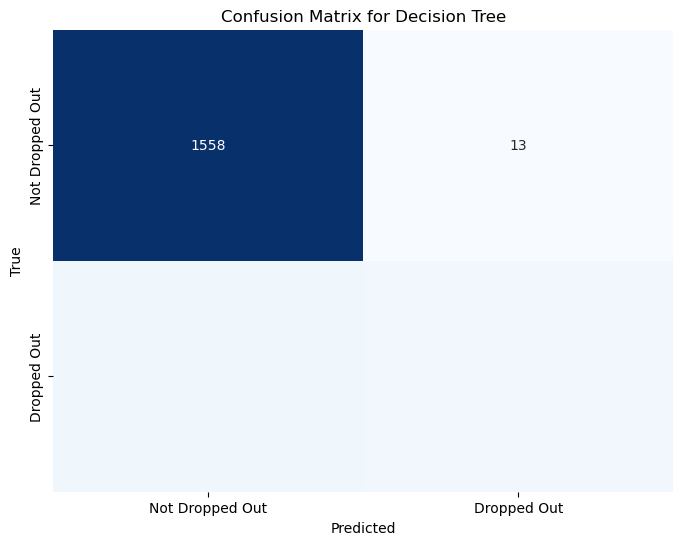

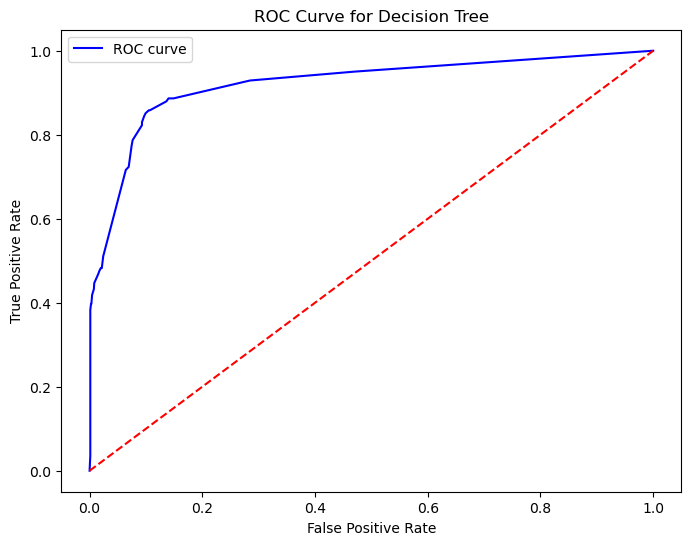


Training Random Forest with hyperparameter tuning...

Best parameters for Random Forest:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1571
           1       0.87      0.41      0.56       141

    accuracy                           0.95      1712
   macro avg       0.91      0.70      0.76      1712
weighted avg       0.94      0.95      0.94      1712


Confusion Matrix for Random Forest:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1562                       9
True: Dropped Out                              83                      58


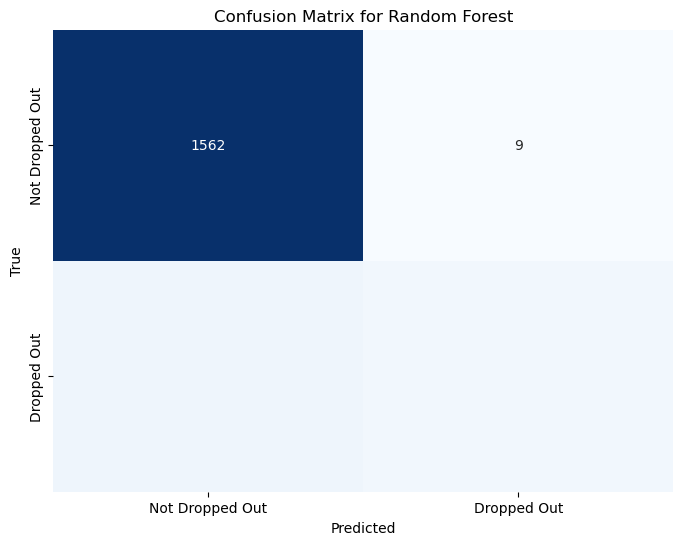

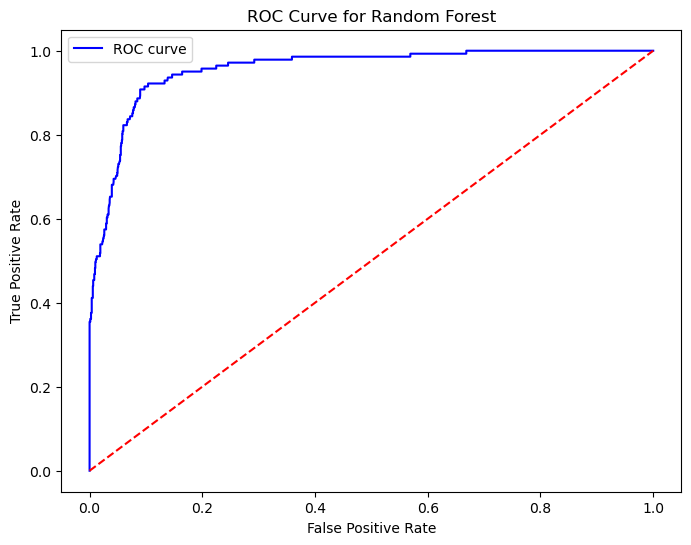


Training Gradient Boosting with hyperparameter tuning...

Best parameters for Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1571
           1       0.87      0.43      0.57       141

    accuracy                           0.95      1712
   macro avg       0.91      0.71      0.77      1712
weighted avg       0.94      0.95      0.94      1712


Confusion Matrix for Gradient Boosting:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1562                       9
True: Dropped Out                              81                      60


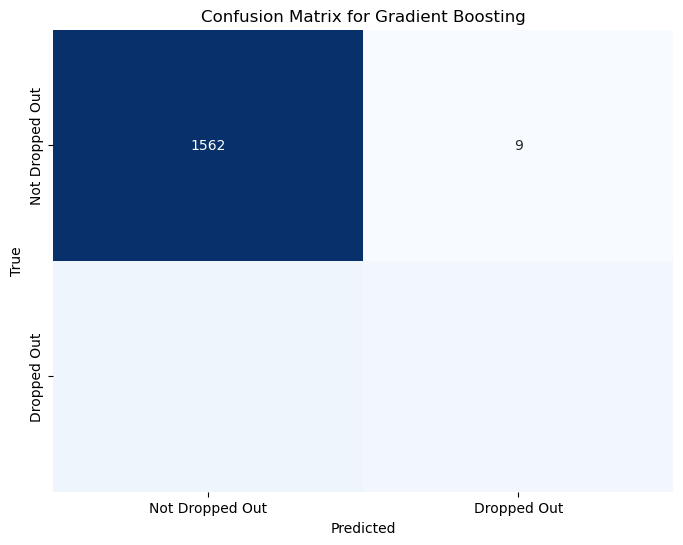

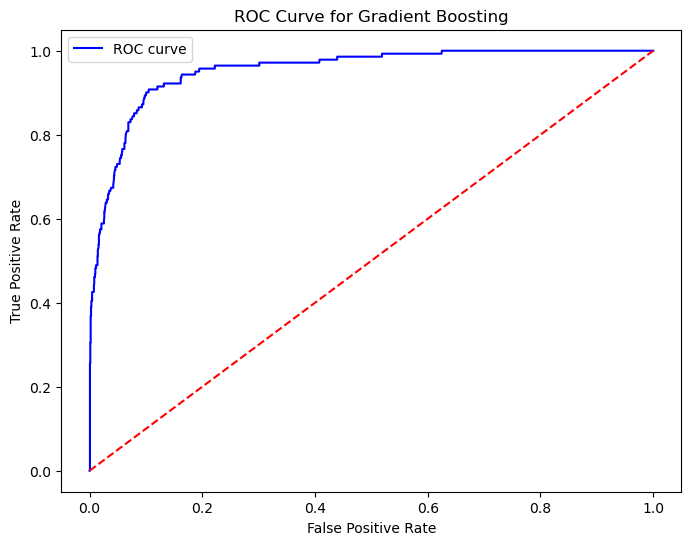


Training Support Vector Machine with hyperparameter tuning...

Best parameters for Support Vector Machine:
{'C': 10, 'kernel': 'rbf'}

Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1571
           1       0.68      0.36      0.47       141

    accuracy                           0.93      1712
   macro avg       0.81      0.67      0.72      1712
weighted avg       0.92      0.93      0.92      1712


Confusion Matrix for Support Vector Machine:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1547                      24
True: Dropped Out                              90                      51


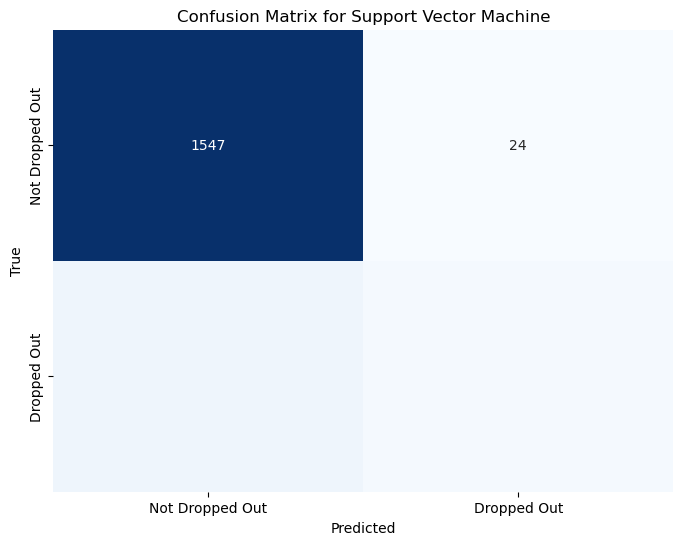

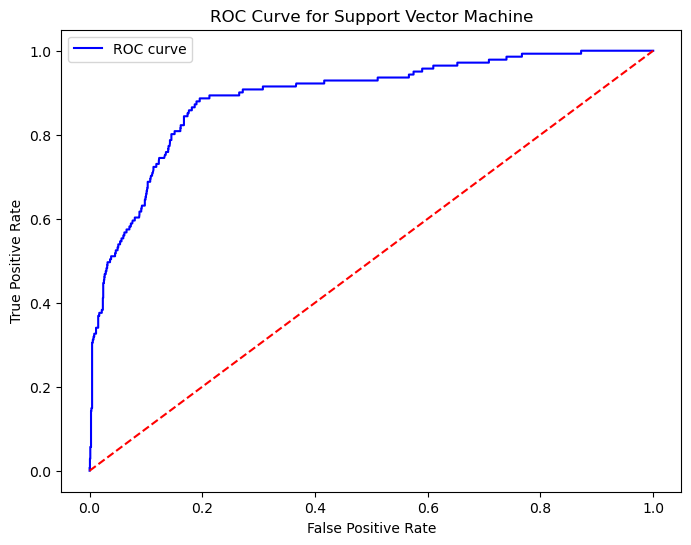


Training K-Neighbors Classifier with hyperparameter tuning...

Best parameters for K-Neighbors Classifier:
{'n_neighbors': 9, 'weights': 'uniform'}

Classification Report for K-Neighbors Classifier:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1571
           1       0.57      0.30      0.39       141

    accuracy                           0.92      1712
   macro avg       0.75      0.64      0.67      1712
weighted avg       0.91      0.92      0.91      1712


Confusion Matrix for K-Neighbors Classifier:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1539                      32
True: Dropped Out                              99                      42


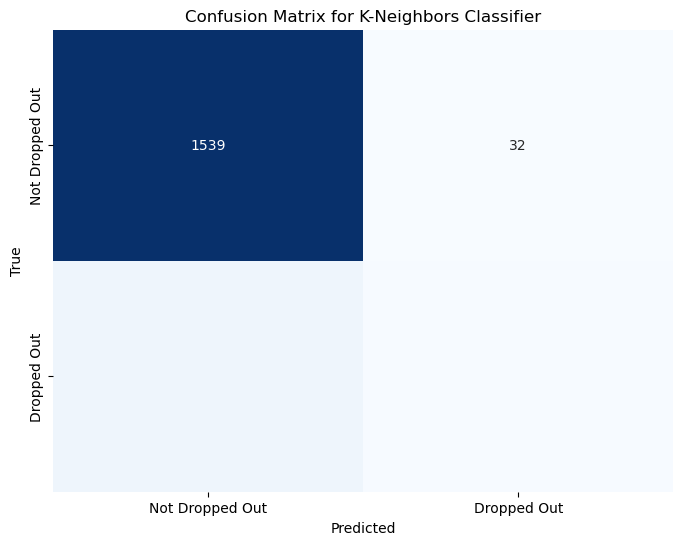

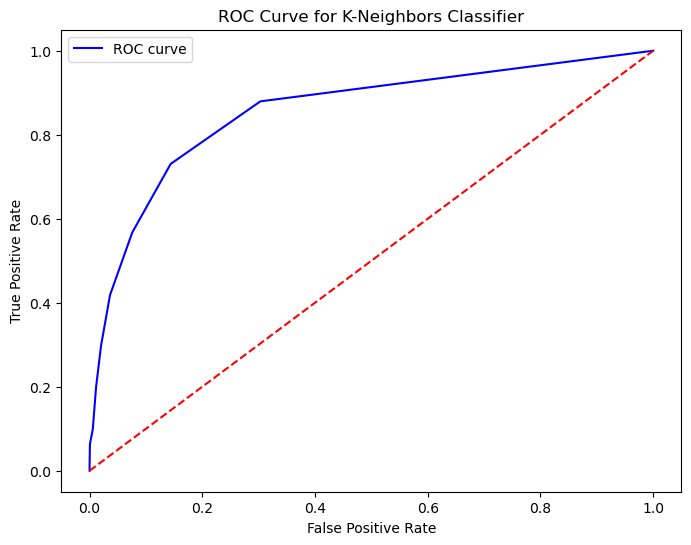


Training XGBoost with hyperparameter tuning...

Best parameters for XGBoost:
{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1571
           1       0.92      0.40      0.56       141

    accuracy                           0.95      1712
   macro avg       0.93      0.70      0.77      1712
weighted avg       0.95      0.95      0.94      1712


Confusion Matrix for XGBoost:

                       Predicted: Not Dropped Out  Predicted: Dropped Out
True: Not Dropped Out                        1566                       5
True: Dropped Out                              84                      57


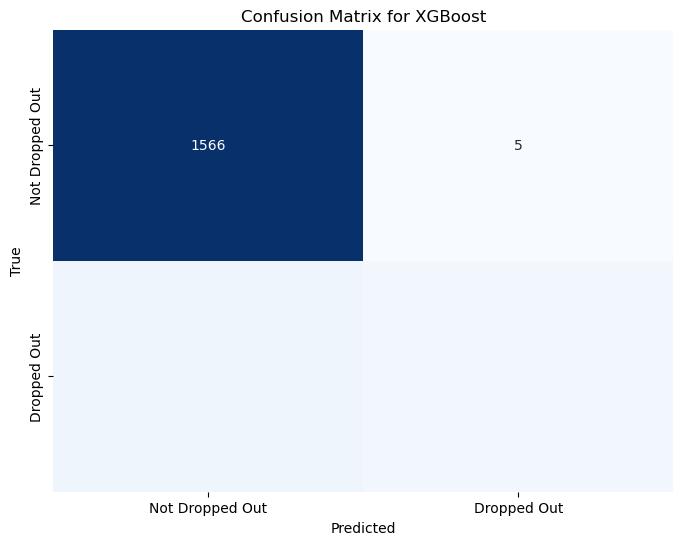

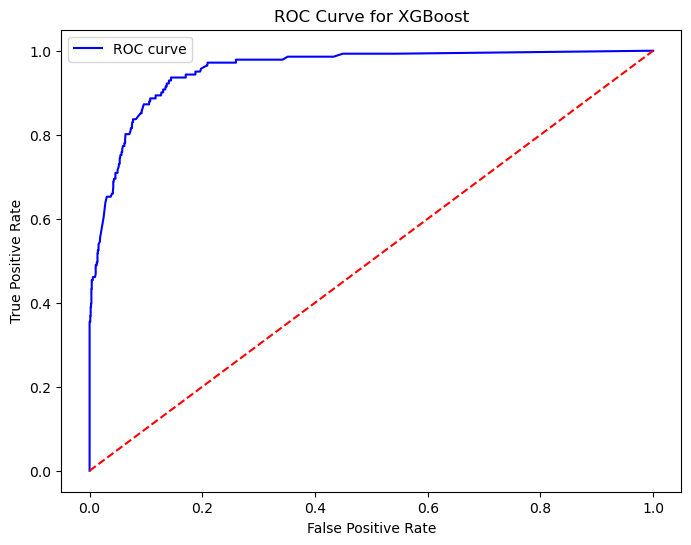

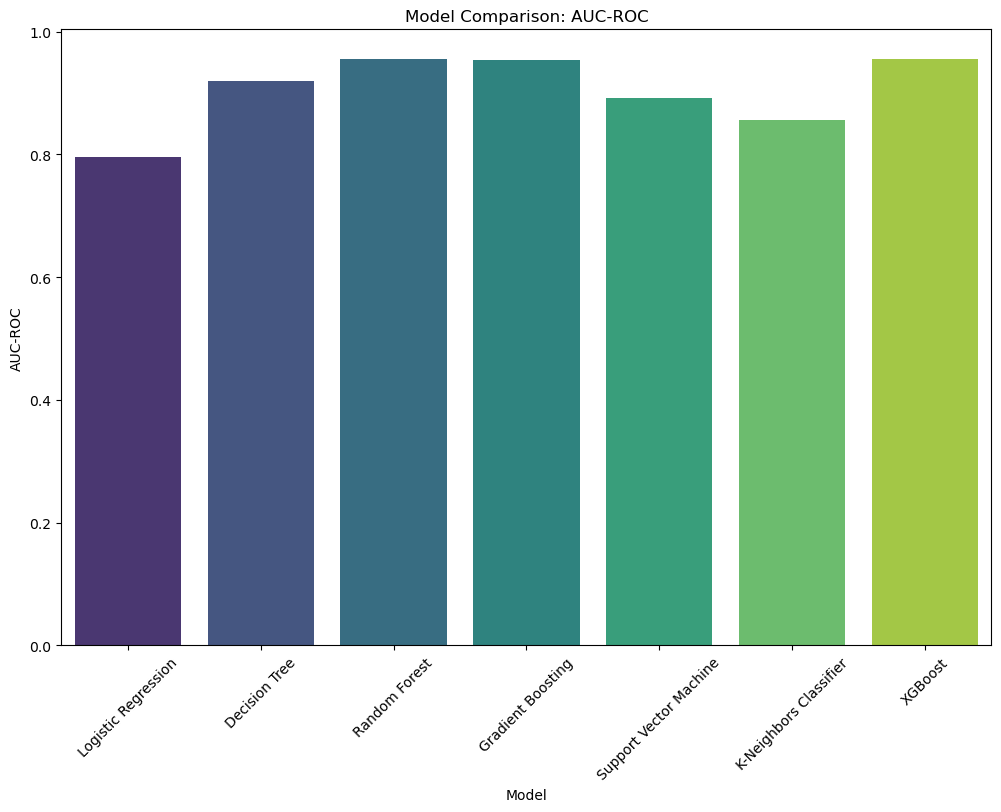

                    Model  Accuracy   AUC-ROC   CV Mean    CV Std  \
0     Logistic Regression  0.796015  0.796015  0.917908  0.000344   
1           Decision Tree  0.920099  0.920099  0.934999  0.003357   
2           Random Forest  0.955910  0.955910  0.940111  0.001312   
3       Gradient Boosting  0.953330  0.953330  0.939673  0.003089   
4  Support Vector Machine  0.891595  0.891635  0.930762  0.002558   
5  K-Neighbors Classifier  0.855944  0.855944  0.919515  0.005709   
6                 XGBoost  0.954603  0.954603  0.938650  0.002123   

                                     Best Parameters  
0  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}  
1         {'max_depth': 10, 'min_samples_split': 10}  
2  {'max_depth': 10, 'min_samples_split': 5, 'n_e...  
3  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...  
4                         {'C': 10, 'kernel': 'rbf'}  
5           {'n_neighbors': 9, 'weights': 'uniform'}  
6  {'learning_rate': 0.01, 'max_depth': 7, 'n_est...  
Saved D

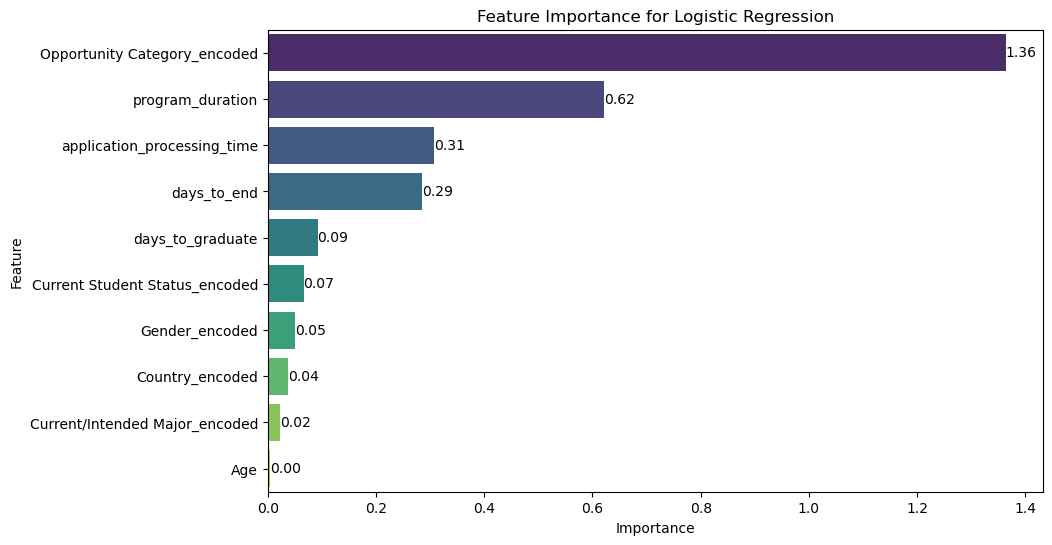

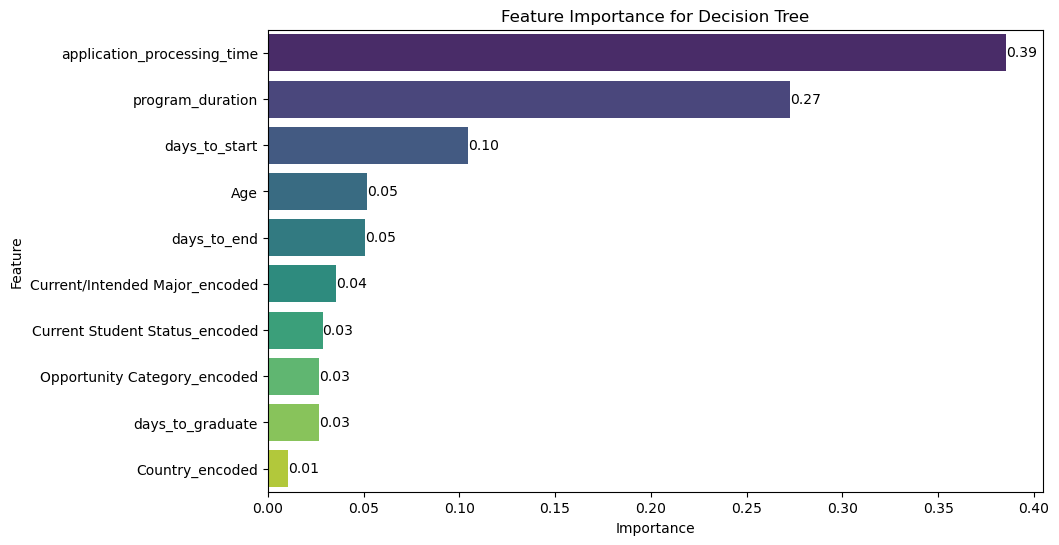

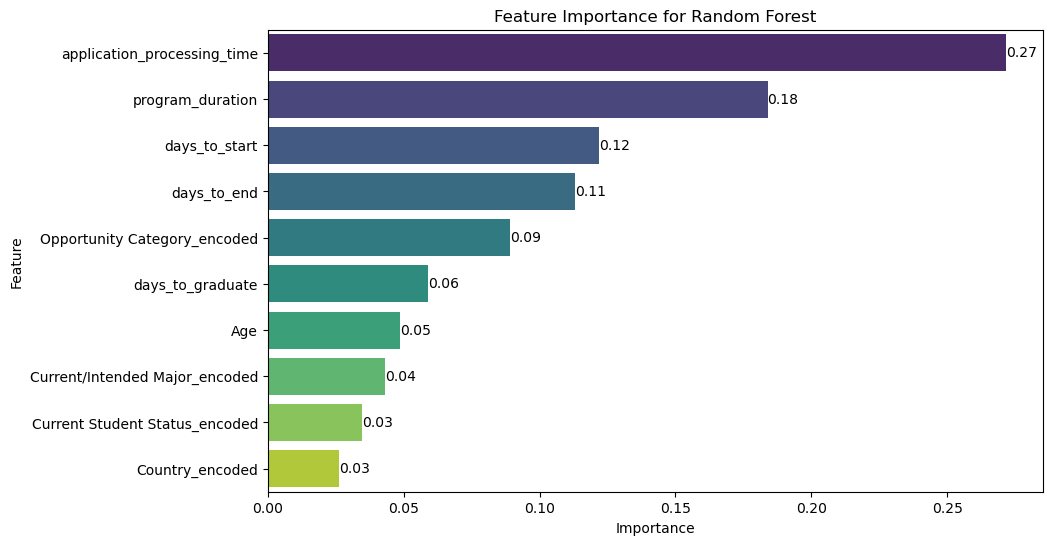

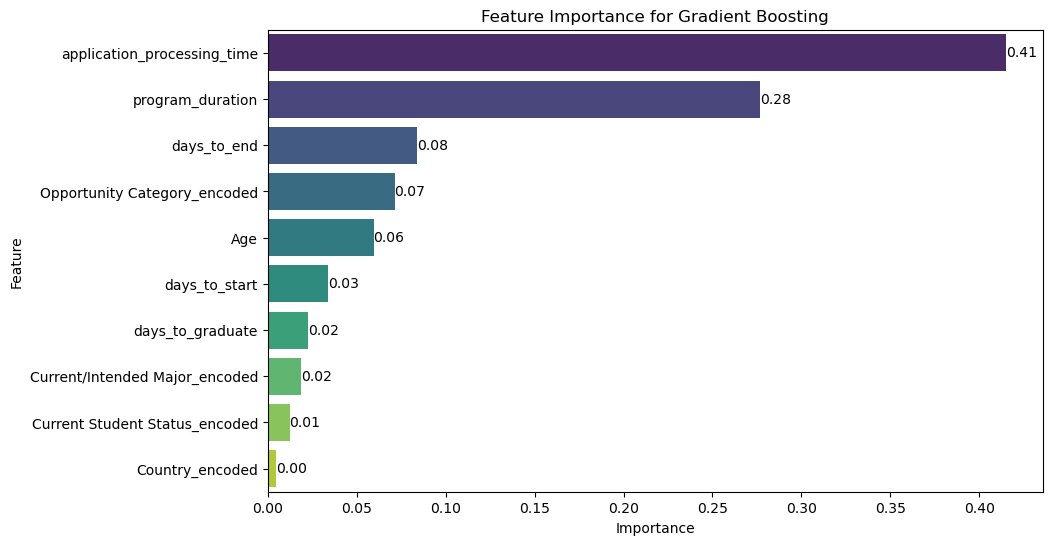

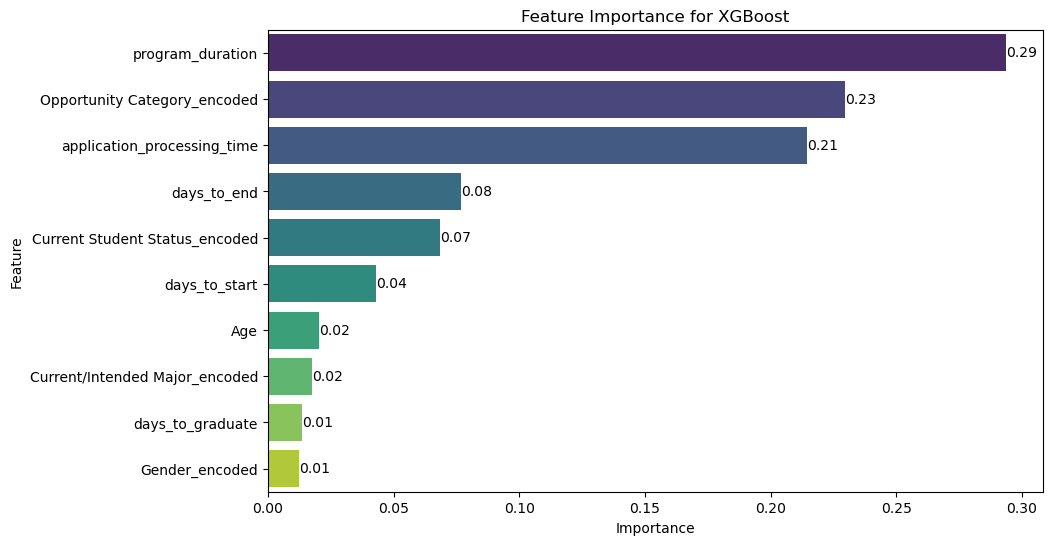

In [13]:
# Example of using the class with a dataframe
df=pd.read_csv(r"C:\Users\vamsh\Downloads\Book1sample.csv")
predictor = AdvancedStudentDropoutPredictor(df)
predictor.prepare_data()
results = predictor.train_and_evaluate_models()
print(results)
predictor.save_best_model('Decision Tree')
predictor.feature_importance_summary()